# Detecção de notícias falsas em português com trechos curtos
### Projeto de Residência em IA — apresentação do processo e do código

**Objetivo:** classificar um **trecho de notícia (até ~50 palavras)** como **true** (verdadeira) ou **fake** (falsa),
com um modelo que **generalize para notícias de fora do corpus de treino** — e não apenas que tire nota alta
no próprio dataset.

**Resultado final:** TF-IDF de n-gramas de caracteres + LinearSVC, treinado em FakeRecogna 2020–21 + um corpus
externo coletado por nós. No teste final (116 notícias reais de set/out 2026, avaliado uma única vez):
**F1 macro 94,2 [IC 95%: 89–99]**, recall de true 100% e recall de fake 83,9%.

---

**Como este notebook está organizado**

| # | Seção | Pergunta que responde |
|---|---|---|
| 0 | [Preparação](#0) | Ambiente, bibliotecas e regras do projeto |
| 1 | [Os dados e o atalho do tamanho](#1) | Por que os ~97% antigos não eram confiáveis? |
| 2 | [Pipeline base](#2) | Truncamento, TF-IDF, LinearSVC e CV agrupada |
| 3 | [Diagnósticos no Fake.br](#3) | O modelo aprende o quê? E em fontes novas? |
| 4 | [FakeRecogna 2.0](#4) | Um segundo corpus ajuda? |
| 5 | [Fase de generalização (E1–E8)](#5) | Coleta externa e experimentos que levaram ao modelo |
| 6 | [Escolha e pré-registro](#6) | Como escolher sem "olhar a prova" |
| 7 | [Avaliação final única](#7) | Quanto o modelo acerta em notícias novas? |
| 8 | [O modelo por dentro](#8) | Quais pedaços de texto pesam para cada classe |
| 9 | [Demonstração](#9) | O modelo em exemplos reais |
| 10 | [Limitações e conclusão](#10) | O que o modelo **não** faz |

<a id="0"></a>
## 0. Preparação

### Regras metodológicas que guiaram todo o projeto

1. **Não ajustar nada olhando o teste.** Hiperparâmetros, dados e escolha de modelo usam só treino/validação.
2. **Cada conjunto tem um papel fixo:** CV interna = referência; split por fonte e corpus externo = validação;
   testes 1 e 2 = **avaliados uma única vez**, no fim, com autorização e pré-registro.
3. **Todo `fit` (TF-IDF, scaler) só no treino de cada fold** — por isso tudo é `Pipeline` do scikit-learn.
4. **CV sempre agrupada por par** (`StratifiedGroupKFold`): no Fake.br cada fake tem uma true "irmã" do mesmo
   tema; se as duas caírem em folds diferentes, o modelo "cola" pelo assunto.
5. **Nunca usar metadados como feature** (autor, link, data, veículo): eles vazam o rótulo.
6. **Diferenças menores que ~1–2 pontos são empate**, principalmente depois de testar várias configurações.

> **Importante para quem for executar:** este notebook **não refaz** coletas nem a avaliação final (isso mudaria os
> dados ou "gastaria" o teste de novo). As etapas pesadas aparecem com o código e os resultados são lidos dos CSVs
> gerados na época. O que roda aqui é rápido (≈1–2 min no total) e serve para reproduzir os números de controle,
> explorar os dados e demonstrar o modelo.

A célula abaixo carrega as bibliotecas e confere a versão do scikit-learn: os modelos `.joblib` foram salvos na
**1.6.1** e a divisão de folds do `StratifiedGroupKFold` muda entre versões.

In [1]:
# Bibliotecas e configuração geral.
import inspect
import os
import re
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from IPython.display import Markdown, display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.precision", 1)

# Scripts do projeto (as funções são importadas para não duplicar código).
import anls
import experimentos
import exp_numeros

print("scikit-learn", sklearn.__version__, "(esperado 1.6.1)")
assert sklearn.__version__ == "1.6.1", "Instale scikit-learn==1.6.1 (ver CONTINUAR.md, seção 1)"

# Cores fixas por classe em todos os gráficos.
COR = {"true": "#2a78d6", "fake": "#eb6834"}
NEUTRO, TINTA, TINTA2 = "#c9c8c2", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#bdbcb6", "axes.labelcolor": TINTA2, "xtick.color": TINTA2, "ytick.color": TINTA2,
    "axes.grid": True, "grid.color": "#e8e7e2", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
})


def mostrar_codigo(*funcs):
    # Mostra o código-fonte de funções dos scripts (para as etapas que não reexecutamos aqui).
    for f in funcs:
        display(Markdown("```python\n" + inspect.getsource(f) + "```"))

scikit-learn 1.6.1 (esperado 1.6.1)


<a id="1"></a>
## 1. Os dados e o atalho do tamanho

### 1.1 Fake.br (corpus de partida)

O Fake.br tem 7.200 notícias (3.600 fake + 3.600 true) organizadas **em pares**: cada fake `i` tem uma true `i`
do mesmo tema. A limpeza aplicada está em `anls.carregar_fakebr`:

- rótulos em minúsculas (`false` → `fake`);
- remoção do caractere invisível BOM (`﻿`) em 10 textos;
- `index` → `pair_id` (usado para agrupar a CV);
- **par 69 removido**: a true dele é idêntica à do par 61 (duplicata) → 7.198 notícias.

In [2]:
# Código da limpeza do Fake.br.
mostrar_codigo(anls.carregar_fakebr)

```python
def carregar_fakebr(caminho=ARQ_FAKEBR):
    # Leitura dos dados originais.
    df = pd.read_csv(caminho, encoding="utf-8")

    # Labels em minúsculas; "false" vira "fake".
    df["label"] = df["label"].astype(str).str.strip().str.lower().replace({"false": "fake"})

    # Remove BOM e colapsa espaços múltiplos.
    df["text"] = (df["text"].astype(str)
                  .str.replace("﻿", "", regex=False)
                  .str.replace(r"\s+", " ", regex=True)
                  .str.strip())

    # index -> pair_id (cada fake i tem uma true i da mesma categoria).
    df = df.rename(columns={"index": "pair_id"})

    # Par 69 removido: a true dos pares 61 e 69 é o mesmo texto.
    df = df[df["pair_id"] != 69].reset_index(drop=True)
    return df
```

In [3]:
# Carrega, confere contra os números esperados e cria a base dos modelos.
df = anls.carregar_fakebr()
anls.conferir_fakebr(df)

df_modelo = df.copy()
df_modelo["n_links"] = df_modelo["n_links"].fillna(0)
df_modelo[["pair_id", "label", "category", "text"]].head(4)

Linhas: 7198 (esperado 7198)
Classes: {'fake': 3599, 'true': 3599} (esperado 3599 cada)
Pares completos fake/true: 3599 de 3599
Pares com mesma categoria: 100.0%
Textos com BOM restantes: 0


,pair_id,label,category,text
0,1,fake,politica,"Kátia Abreu diz que vai colocar sua expulsão em uma moldura, mas não para de reclamar. A senadora Kátia Abreu (sem p..."
1,10,fake,politica,"Dr. Ray peita Bolsonaro, chama-o de conservador fake em entrevista a Danilo Gentili e divide a direita. Este site ..."
2,100,fake,politica,Reinaldo Azevedo desmascarado pela Polícia Federal. O mais ferrenho crítico do presidenciável Jair Bolsonaro foi des...
3,1000,fake,politica,Relatório assustador do BNDES mostra dinheiro público DO BRASIL jorrando em países comunistas. . Um relatório intitu...


### 1.2 Dois achados que mudaram o rumo do projeto

**(a) O tamanho do texto separa as classes quase sozinho.** As true têm em média ~6× mais caracteres que as fake.

,mean,25%,50%,75%
label,,,,
fake,1116.0,692.0,952.0,1348.0
true,6673.0,3872.0,5582.0,8586.0


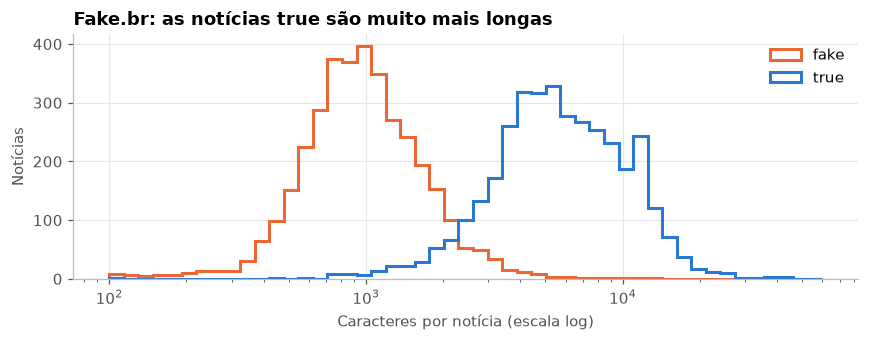

In [4]:
# Tamanho (caracteres) por classe.
df_modelo["n_caracteres"] = df_modelo["text"].str.len()
display(df_modelo.groupby("label")["n_caracteres"].describe()[["mean", "25%", "50%", "75%"]].round(0))

# Histograma em escala log: as duas distribuições quase não se sobrepõem.
fig, ax = plt.subplots(figsize=(8, 3.2))
bins = np.logspace(np.log10(100), np.log10(60000), 50)
for lab in ("fake", "true"):
    ax.hist(df_modelo.loc[df_modelo["label"] == lab, "n_caracteres"], bins=bins, histtype="step",
            linewidth=2, color=COR[lab], label=lab)
ax.set_xscale("log")
ax.set_xlabel("Caracteres por notícia (escala log)")
ax.set_ylabel("Notícias")
ax.set_title("Fake.br: as notícias true são muito mais longas")
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

**(b) Cada classe vem de poucos sites.** 92,7% das fake são de um único site (Diário do Brasil) e as true são de
G1/Estadão/Folha. Um modelo pode aprender "estilo do Diário do Brasil × estilo do G1" em vez de "fake × true".

In [5]:
# Domínio de cada notícia (usado só para diagnóstico; NUNCA como feature).
dominio = df_modelo["link"].astype(str).str.extract(r"https?://(?:www\.)?([^/]+)")[0].str.lower()
dominio = dominio.str.replace(r"^.*estadao.*$", "estadao (todos)", regex=True)
fontes = dominio.groupby(df_modelo["label"]).value_counts().rename("n").reset_index()
fontes["% da classe"] = 100 * fontes["n"] / fontes.groupby("label")["n"].transform("sum")
fontes.groupby("label").head(4)

,label,0,n,% da classe
0,fake,diariodobrasil.org,3337,9.3e+01
1,fake,afolhabrasil.com.br,173,4.8e+00
2,fake,thejornalbrasil.com.br,66,1.8e+00
3,fake,ceticismopolitico.com,16,4.4e-01
5,true,g1.globo.com,2299,6.4e+01
6,true,estadao (todos),1203,3.3e+01
7,true,www1.folha.uol.com.br,91,2.5e+00
8,true,territorioeldorado.limao.com.br,2,5.6e-02


### 1.3 Número de controle 1 — um modelo que só vê o tamanho

Para medir o atalho, treinamos um classificador cuja **única feature é `log(n_caracteres)`**. Se ele chegar perto
dos ~97% históricos, a nota alta não diz nada sobre detectar notícias falsas. Esperado: **~94,2% de accuracy**.

In [6]:
# Baseline só tamanho: log1p(n_caracteres) + StandardScaler + LinearSVC, CV agrupada por par, texto completo.
res_tamanho = anls.controle_tamanho(df_modelo)

Controle 1 - só tamanho (len(text)): accuracy 94.15 (std 0.68) | F1 macro 94.15 (std 0.68)


           - só tamanho (n_characters): accuracy 94.25 (std 0.65) | F1 macro 94.25 (std 0.65)


> **Conclusão:** só o tamanho dá ~94%. Os ~97% históricos vinham em grande parte desse atalho. No produto real a
> entrada é um **trecho curto**, onde o tamanho não existe como pista. Daí a decisão central do projeto:
> **treinar e avaliar sempre com textos truncados.**

<a id="2"></a>
## 2. Pipeline base

### 2.1 Truncamento e aumento de dados

- `truncar(s, N)`: mantém só as N primeiras palavras.
- `aumentar(textos, labels)`: cada texto de treino entra **três vezes**, cortado em 30, 50 e 100 palavras
  (treino misto). Assim o modelo vê trechos de vários tamanhos e não depende de um tamanho específico.

In [7]:
# Funções de truncamento (anls.py).
mostrar_codigo(anls.truncar, anls.aumentar)

# Exemplo: o mesmo texto em 30 palavras.
exemplo = df_modelo["text"].iloc[[0]]
print("Original:", len(exemplo.iloc[0].split()), "palavras")
print("N=30   :", anls.truncar(exemplo, 30).iloc[0])

```python
def truncar(s, N):
    return s.str.split().str[:N].str.join(" ")
```

```python
def aumentar(textos, labels):
    t, l = pd.Series(list(textos)), pd.Series(list(labels))
    return (pd.concat([truncar(t, n) for n in (30, 50, 100)], ignore_index=True),
            pd.concat([l] * 3, ignore_index=True))
```

Original: 182 palavras
N=30   : Kátia Abreu diz que vai colocar sua expulsão em uma moldura, mas não para de reclamar. A senadora Kátia Abreu (sem partido-TO) disse que sua expulsão do PMDB foi resultado


### 2.2 Modelo e validação

- **TF-IDF**: transforma o texto em um vetor de pesos de palavras/bigramas (frequente no texto e raro no corpus =
  peso alto).
- **LinearSVC**: classificador linear; cada n-grama recebe um peso positivo (empurra para *true*) ou negativo
  (empurra para *fake*). A decisão é `score ≥ 0 → true`.
- **`class_weight="balanced"`**: usado quando o treino mistura corpora com classes desbalanceadas.
- **`StratifiedGroupKFold`**: 5 folds, mantendo a proporção de classes e os pares fake/true no mesmo fold.

In [8]:
# Fábricas do modelo e a CV oficial (anls.py).
mostrar_codigo(anls.novo_tfidf, anls.novo_tfidf_bal, anls.base_truncada)
print(anls.cv)

```python
def novo_tfidf():
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), dtype=np.float32)),
        ("svm", LinearSVC(C=1.0, max_iter=20000))
    ])
```

```python
def novo_tfidf_bal():
    return Pipeline([
        ("tfidf", TfidfVectorizer(max_features=50000, ngram_range=(1, 2), dtype=np.float32)),
        ("svm", LinearSVC(C=1.0, max_iter=20000, class_weight="balanced"))
    ])
```

```python
def base_truncada(df, N):
    n_palavras = df["text"].str.split().str.len()
    pares_ok = n_palavras.groupby(df["pair_id"]).min() >= N
    d = df[df["pair_id"].isin(pares_ok[pares_ok].index)].copy()
    d["text"] = truncar(d["text"], N)
    return d.reset_index(drop=True)
```

StratifiedGroupKFold(n_splits=5, random_state=42, shuffle=True)


### 2.3 Número de controle 2 — TF-IDF com trechos de 50 palavras

Só entram pares em que **as duas** notícias têm pelo menos 50 palavras (todos os textos ficam exatamente com 50
palavras, então o tamanho deixa de ser pista). Esperado: **~89,9% de F1 macro**.

In [9]:
# TF-IDF word(1,2) + LinearSVC em textos de 50 palavras, CV agrupada por par.
res_n50 = anls.controle_tfidf_n50(df_modelo)

N=50: 3500 pares (esperado 3500)


Controle 2 - TF-IDF N=50: accuracy 89.89 (std 0.63) | F1 macro 89.88 (std 0.63)


> Os dois controles batem com o notebook original (94,17% / 89,88%), o que confirma que o ambiente e o pipeline
> foram reproduzidos corretamente antes de qualquer experimento novo.

<a id="3"></a>
## 3. Diagnósticos no Fake.br (o que o modelo aprende?)

Estes experimentos foram feitos no notebook original (`caio.ipynb`) e estão registrados no `README.md`
(seções 5.2–5.8). Os números abaixo **não são reexecutados aqui**; servem para explicar as decisões.

**Truncamento (CV agrupada, F1 macro %)** — o truncamento neutraliza o tamanho (~55%) e o TF-IDF se mantém em 87–91%:

| N palavras | Pares | Só tamanho | TF-IDF | 9 features linguísticas (spaCy) | Híbrido 50/50 |
|---:|---:|---:|---:|---:|---:|
| 30 | 3.545 | 55,8 | 87,4 | 64,5 | 81,5 |
| 50 | 3.500 | 56,9 | **89,9** | 66,4 | 83,3 |
| 100 | 2.993 | 55,5 | 90,9 | 69,4 | 85,4 |

**Mascaramento progressivo (N=50)** — escondendo nomes, números, datas e termos políticos o F1 cai só ~2 pontos;
só despenca quando sobra apenas a gramática. **O modelo aprende sobretudo estilo de redação, não o assunto.**

| Versão | F1 | Queda |
|---|---:|---:|
| Original | 89,5 | — |
| + entidades, números, veículos, datas, nomes próprios mascarados | 87,2 | −2,3 |
| Só palavras funcionais + classe gramatical | 82,0 | −7,5 |
| Só sequência de classes gramaticais | 80,2 | −9,4 |

**Split por fonte** — treino só com Diário do Brasil (fake) + G1 (true), teste nas outras fontes:

| Modelo | Mesma fonte (F1) | Fonte nova (bal. acc) |
|---|---:|---:|
| TF-IDF | 91,5 | **74,3** |
| 9 features linguísticas | — | 62,6 |
| Stacking TF-IDF + features | — | 74,6 (peso das features ≈ 0) |

**Tamanho do treino (validação por fonte, bal. acc)** — treinar com texto completo faz o modelo chamar quase todo
trecho curto de fake (o "colapso" histórico); o treino misto é o melhor nos três tamanhos:

| Treino | Teste 30 | Teste 50 | Teste 100 |
|---|---:|---:|---:|
| N=50 | 73,0 | 74,7 | 68,6 |
| **Misto 30/50/100** | **73,8** | **75,5** | **70,1** |
| Texto completo | 50,1 | 50,4 | 51,7 |

> **Decisões tiradas daqui:** só TF-IDF (features linguísticas, híbrido e mascaramento não ajudam), treino misto
> 30/50/100 e entrada do produto de até ~50 palavras. **O gargalo é de dados** (fake de um só site): mudar de
> fonte custa ~17 pontos, e um grid de 48 hiperparâmetros só deu empates (74,2–74,9).

<a id="4"></a>
## 4. FakeRecogna 2.0 (segundo corpus)

Corpus do Hugging Face (`recogna-nlp/fakerecogna2-abstrativa`, 52.800 textos) com fake vindas de **9 agências de
checagem**. Cuidados no carregamento (`anls.carregar_fakerecogna`):

- o rótulo é invertido (`1 = fake`);
- muitos textos fake são **a checagem**, não o boato. Classificamos cada fake em `boato_citado` (começa com o boato
  entre aspas → usamos só as aspas), `texto_checagem` (vocabulário de agência: "falso", "boato", "viralizou"…) e
  `outros`; as `texto_checagem` ficam **fora** do treino;
- as true são **resumos automáticos** e estão concentradas em 2020–2021, então só esses dois anos são usados
  (com todos os anos, o modelo aprende "assunto da época = fake").

In [10]:
# Classificação dos textos do FakeRecogna e recorte usado no treino.
mostrar_codigo(anls.treino_candidato)
df_rec2 = anls.carregar_fakerecogna()
display(df_rec2["tipo"].value_counts().rename("n").to_frame())

# Distribuição por ano: só 2020 e 2021 têm as duas classes em quantidade.
anos = df_rec2.dropna(subset=["ano"]).query("2016 <= ano <= 2023")
display(pd.crosstab(anos["ano"].astype(int), anos["label"]).T)

```python
def treino_candidato(df_modelo, df_rec2):
    # Treino do candidato: Fake.br completo + FakeRecogna 2020–2021 (fake sem checagem + true balanceadas).
    fr = df_rec2[df_rec2["ano"].isin([2020, 2021])]
    fr_fake = fr[fr["tipo"].isin(["fake_boato_citado", "fake_outros"])]
    fr_true = fr[fr["tipo"] == "true_resumida"].sample(len(fr_fake), random_state=SEED)
    X = pd.concat([df_modelo["text"], fr_fake["texto_base"], fr_true["texto_base"]], ignore_index=True)
    y = pd.concat([df_modelo["label"], fr_fake["label"], fr_true["label"]], ignore_index=True)
    return X, y
```

,n
tipo,
true_resumida,26400
fake_outros,17572
fake_texto_checagem,6670
fake_boato_citado,2158


ano,2016,2017,2018,2019,2020,2021,2022,2023
label,,,,,,,,
fake,485,1253,2135,2632,3449,2644,3217,1761
true,0,0,0,24,10906,13968,222,0


No Fake.br, adicionar o FakeRecogna 2020 ao treino subiu a validação no FakeRecogna 2021 de 69 para **83** sem
piorar no Fake.br. Esse modelo virou o **candidato** (`modelo_candidato_fakebr_fakerecogna.joblib`).

Mas ainda havia um problema: **nenhum dos dois corpora tem o formato do produto** (boato real × início de matéria
jornalística de hoje). Sem dados nesse formato não dá para medir, nem melhorar, a generalização sem "olhar o teste".

<a id="5"></a>
## 5. Fase de generalização externa (E1–E8)

Plano definido **antes** de ver qualquer resultado (registrado no `EXPERIMENTOS.md`):

| Etapa | O quê | Por quê |
|---|---|---|
| E1 | Coletar o teste externo (e guardar) | Medida final, usada uma vez só |
| E2 | Coletar um corpus externo de treino/validação | Ter dados no formato do produto para escolher sem tocar no teste |
| E3 | Modelos antigos na validação externa | Ponto de partida |
| E4 | Combinações de dados | O limite identificado era de dados |
| E5 | Variações de modelo | Caracteres captam CAIXA ALTA, pontuação, grafia de boato |
| E6 | Treinar sem uma fonte e validar nela | Separar generalização real de "assinatura de site" |
| E7 | Embeddings pré-treinados | Representação semântica, menos dependente do vocabulário |
| E8 | Feature de números (hipótese do grupo) | "Notícia verdadeira cita mais números" |

**Métrica principal:** F1 macro na validação externa, com a entrada cortada em **50 palavras** (formato do produto).

### 5.1 Coleta automática (E1 e E2)

Tudo via RSS, **sem escolha manual** de notícias:

- **true:** Agência Brasil e G1 → início da matéria, sem título, sem legendas/assinaturas, até 60 palavras;
- **fake:** Boatos.org e E-farsas → o maior `blockquote` da página (o boato citado), ignorando embeds de redes
  sociais e marcadores da agência ("Versão 1:").

Conferência manual permitida **só por conteúdo** (ex.: trecho de fake que era o desmentido oficial), nunca pela
previsão do modelo. O código abaixo é só exibido: rodar de novo mudaria os dados.

In [11]:
# Extração dos trechos (coletar_teste_externo.py) — NÃO reexecutar a coleta.
import coletar_teste_externo
mostrar_codigo(coletar_teste_externo.extrair_true, coletar_teste_externo.extrair_fake)

```python
def extrair_true(html, titulo):
    corpo = trafilatura.extract(html, include_comments=False, include_tables=False) or ""
    linhas = [l.strip() for l in corpo.split("\n") if l.strip()]

    # Remove o título quando o extrator o inclui (Agência Brasil inclui, G1 não).
    if linhas and linhas[0].strip().lower() == titulo.strip().lower():
        linhas = linhas[1:]

    # Remove linhas de navegação/lixo de página e marcadores gráficos.
    lixo = re.compile(r"^(leia (também|mais)|veja (também|mais)|assista|📲|siga o|clique aqui)", re.I)
    linhas = [re.sub(r"^[➡▶►•✅📌🔴]+\s*", "", l) for l in linhas if not lixo.match(l)]

    # Remove legendas de foto ("... — Foto: crédito").
    linhas = [l for l in linhas if not re.search(r"—\s*Foto:", l)]

    # Remove assinatura com data ("Por Fulano, ... 30/09/2026 14h03 Atualizado ..."), que vem quebrada em linhas.
    texto = " ".join(linhas)
    texto = re.sub(r"Por\s[^.]*?\d{2}/\d{2}/\d{4}\s+\d{2}h\d{2}(\s+Atualizado(\s+há)?\s+\S+(\s+\d{2}/\d{2}/\d{4})?)?\s*",
                   "", texto)
    return limpar_e_cortar(texto)
```

```python
def extrair_fake(html):
    sopa = BeautifulSoup(html, "html.parser")
    candidatos = []
    for bq in sopa.find_all("blockquote"):
        classes = " ".join(bq.get("class") or [])
        texto = " ".join(bq.get_text(" ").split())
        if any(c in classes for c in CLASSES_EMBED) or texto.startswith("@"):
            continue
        candidatos.append(texto)
    if not candidatos:
        return "", 0
    maior = max(candidatos, key=lambda t: len(t.split()))
    # Remove marcadores inseridos pela agência ("Versão 1:", "Versão 2:"), que não fazem parte do boato.
    maior = re.sub(r"Vers[ãa]o \d+\s*:\s*", " ", maior, flags=re.I)
    # Remove aspas nas pontas (o boato costuma vir entre aspas).
    maior = maior.strip(" \"“”'‘’")
    return limpar_e_cortar(maior), len(candidatos)
```

### 5.2 Preparação do corpus externo (E2)

`experimentos.preparar_corpus_externo`: mínimo de palavras, remoção de duplicados, **descontaminação** (remove
qualquer item com similaridade de cosseno ≥ 0,8 com algum texto do teste — usando só o texto, sem rótulo) e divisão
70/30. Nas fake, a validação recebe os **30% mais recentes** de cada agência, imitando o teste, que é o mais recente.

In [12]:
# Código da preparação (já executado em 01/10/2026; o resultado está em dados_externos/corpus_externo.csv).
mostrar_codigo(experimentos.preparar_corpus_externo)

```python
def preparar_corpus_externo():
    c = pd.read_csv(os.path.join(PASTA, "corpus_externo_bruto.csv"))
    c["texto"] = c["texto"].fillna("")
    n0 = len(c)

    # Mínimos do notebook (célula 59): boato >= 20 palavras, início de matéria >= 30.
    minimo = np.where(c["label"] == "fake", 20, 30)
    c = c[c["n_palavras"] >= minimo]
    n1 = len(c)

    # Textos repetidos (mesmo boato em posts diferentes) ficam uma vez só.
    c = c.drop_duplicates("texto")
    n2 = len(c)

    # Descontaminação: remove itens quase idênticos a qualquer texto do teste (cosseno >= 0,8).
    # Usa apenas os textos do teste (sem label e sem modelo), só para evitar vazamento de conteúdo.
    teste = pd.read_csv("teste_externo_2026_bruto.csv")["texto"]
    vec = TfidfVectorizer().fit(pd.concat([c["texto"], teste]))
    sim = cosine_similarity(vec.transform(c["texto"]), vec.transform(teste)).max(axis=1)
    c = c[sim < 0.8]
    n3 = len(c)

    # Data de publicação.
    c["dt"] = pd.to_datetime(c["data"], utc=True, errors="coerce", format="mixed")

    # Divisão: fake -> 30% mais recentes de cada agência na validação; true -> 30% aleatório por fonte.
    c["split"] = "treino"
    for fonte, g in c.groupby("fonte"):
        n_val = int(round(0.3 * len(g)))
        if g["label"].iloc[0] == "fake":
            idx_val = g.sort_values("dt", ascending=False).index[:n_val]
        else:
            idx_val = g.sample(n_val, random_state=SEED).index
        c.loc[idx_val, "split"] = "val"

    print(f"Corpus externo: {n0} brutos -> {n1} com mínimo de palavras -> {n2} sem duplicados "
          f"-> {n3} após descontaminação")
    print(c.groupby(["split", "label", "fonte"]).agg(n=("link", "size"),
                                                     de=("dt", "min"), ate=("dt", "max")))
    c.to_csv(os.path.join(PASTA, "corpus_externo.csv"), index=False, encoding="utf-8-sig")
    return c
```

In [13]:
# Corpus externo pronto: tamanho e período de cada fonte em cada split.
corpus = pd.read_csv("dados_externos/corpus_externo.csv")
corpus["dt"] = pd.to_datetime(corpus["dt"], utc=True)
(corpus.groupby(["split", "label", "fonte"])
       .agg(n=("texto", "size"), de=("dt", lambda s: s.min().date()), ate=("dt", lambda s: s.max().date())))

n          de         ate
split  label fonte                                       
treino fake  Boatos.org       567  2025-11-27  2026-07-19
             E-farsas          78  2022-05-11  2024-07-20
       true  Agência Brasil    72  2026-09-24  2026-10-01
             G1              1277  2026-08-08  2026-10-01
val    fake  Boatos.org       243  2026-07-19  2026-09-27
             E-farsas          34  2024-07-23  2026-03-04
       true  Agência Brasil    31  2026-09-26  2026-10-01
             G1               547  2026-08-07  2026-10-01

**Observações:** classes desbalanceadas (por isso F1 macro e `class_weight="balanced"`); E-farsas e Agência Brasil
são pequenos (~30 itens na validação, variação alta); e há um **descompasso temporal** (fake até jul/2026 × true de
ago–out/2026) que pode criar um atalho de "assunto da época" — registrado como limitação.

### 5.3 Protocolo de avaliação

Todo experimento passa pela mesma função: corta a validação em 50 palavras, calcula F1 macro, balanced accuracy,
recall por classe e acerto por fonte, e **acrescenta uma linha** em `resultados_experimentos.csv`. Assim nenhum
número é digitado à mão.

In [14]:
mostrar_codigo(experimentos.avaliar, experimentos.juntar, experimentos.treinar)

# Todos os resultados da fase de generalização.
res = pd.read_csv("resultados_experimentos.csv")
COLS = ["experimento", "f1_macro", "bal_acc", "recall_fake", "recall_true",
        "acerto_Agência Brasil", "acerto_Boatos.org", "acerto_E-farsas", "acerto_G1"]


def tabela(grupo):
    return res.loc[res["grupo"] == grupo, COLS].set_index("experimento")


def barras(t, destaque, titulo, xlim=(60, 95)):
    # Barras horizontais de F1 macro; o item escolhido em azul, os demais em cinza.
    t = t.sort_values("f1_macro")
    fig, ax = plt.subplots(figsize=(8, 0.32 * len(t) + 0.9))
    cores = [COR["true"] if i == destaque else NEUTRO for i in t.index]
    ax.barh(t.index, t["f1_macro"], color=cores, height=0.7)
    for y, v in enumerate(t["f1_macro"]):
        ax.text(v + 0.3, y, f"{v:.1f}", va="center", fontsize=9, color=TINTA2)
    ax.set_xlim(*xlim); ax.set_xlabel("F1 macro na validação externa (%)")
    ax.grid(axis="y", visible=False); ax.set_title(titulo)
    plt.tight_layout(); plt.show()

```python
def avaliar(modelo, val, nome, grupo, obs="", pred_fn=None):
    # Avalia no formato do produto (até 50 palavras) e registra no CSV de resultados.
    X = truncar(val["texto"], N_PRODUTO)
    pred = pred_fn(X) if pred_fn else modelo.predict(X)
    y = val["label"]
    linha = {
        "grupo": grupo, "experimento": nome,
        "f1_macro": f1_score(y, pred, average="macro") * 100,
        "bal_acc": balanced_accuracy_score(y, pred) * 100,
        "recall_fake": recall_score(y, pred, pos_label="fake") * 100,
        "recall_true": recall_score(y, pred, pos_label="true") * 100,
        "n_val": len(val), "obs": obs, "quando": time.strftime("%Y-%m-%d %H:%M"),
    }
    # Acerto por fonte (para ver se o ganho vem de uma fonte só).
    for fonte, g in val.assign(ok=(pred == y.values)).groupby("fonte"):
        linha[f"acerto_{fonte}"] = g["ok"].mean() * 100
    df = pd.DataFrame([linha])
    if os.path.exists(ARQ_RESULTADOS):
        df = pd.concat([pd.read_csv(ARQ_RESULTADOS), df], ignore_index=True)
    df.to_csv(ARQ_RESULTADOS, index=False, encoding="utf-8-sig")
    print(f"[{grupo}] {nome}: F1 {linha['f1_macro']:.2f} | bal_acc {linha['bal_acc']:.2f} | "
          f"rec_fake {linha['recall_fake']:.2f} | rec_true {linha['recall_true']:.2f} | "
          + " ".join(f"{k[7:]} {v:.1f}" for k, v in linha.items() if k.startswith("acerto_")))
    return linha
```

```python
def juntar(fontes, nomes, repetir_ext=1):
    # Concatena as fontes pedidas; "ext" pode ser repetido para ganhar peso frente aos corpora grandes.
    Xs, ys = [], []
    for n in nomes:
        X, y = fontes[n]
        k = repetir_ext if n == "ext" else 1
        Xs += [X] * k
        ys += [y] * k
    return pd.concat(Xs, ignore_index=True), pd.concat(ys, ignore_index=True)
```

```python
def treinar(X, y, fabrica=novo_tfidf_bal, misto=True):
    # Treino no esquema vigente: truncamento misto 30/50/100 (decisão da seção 5.8).
    if misto:
        X, y = aumentar(X, y)
    return fabrica().fit(X, y)
```

### 5.4 E3 — Ponto de partida

Os dois modelos antigos, sem nenhum ajuste, na validação externa (855 itens):

In [15]:
tabela("E3 base")

,f1_macro,bal_acc,recall_fake,recall_true,acerto_Agência Brasil,acerto_Boatos.org,acerto_E-farsas,acerto_G1
experimento,,,,,,,,
modelo_final (só Fake.br),79.9,78.8,66.4,91.2,100.0,70.8,35.3,90.7
modelo_candidato (Fake.br + FR 2020-21),82.9,83.0,77.3,88.8,96.8,81.1,50.0,88.3


### 5.5 E4 — Quais dados de treino?

Mesmo modelo (TF-IDF palavras + LinearSVC balanceado, treino misto), variando só os dados.
`fb` = Fake.br, `fr2021` = FakeRecogna 2020–21, `frall` = FakeRecogna todos os anos, `ext` = treino do corpus externo.

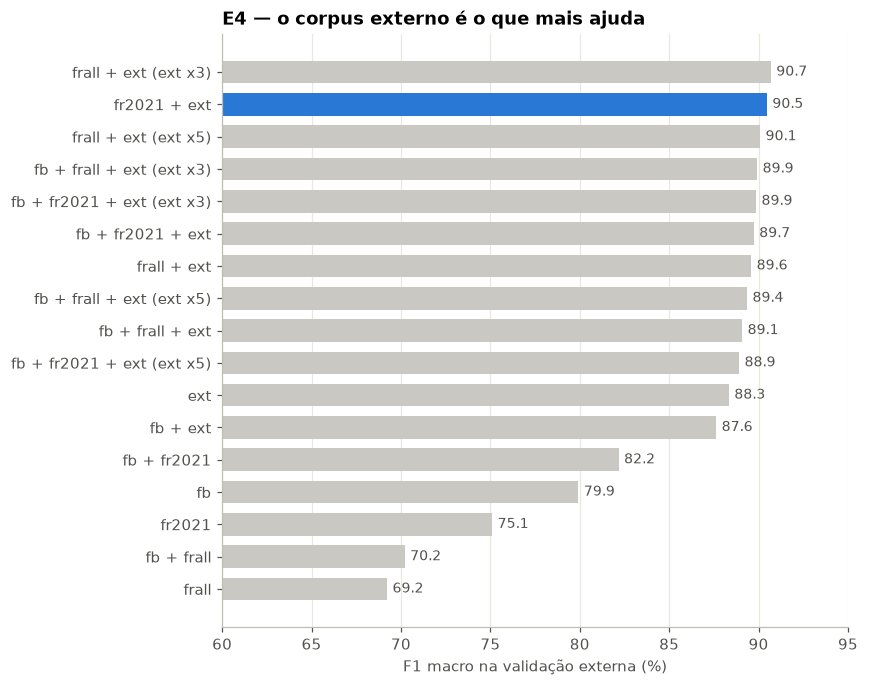

,f1_macro,bal_acc,recall_fake,recall_true,acerto_Agência Brasil,acerto_Boatos.org,acerto_E-farsas,acerto_G1
experimento,,,,,,,,
frall + ext (ext x3),90.7,90.3,85.6,95.0,96.8,87.2,73.5,94.9
fr2021 + ext,90.5,89.7,83.8,95.7,96.8,87.2,58.8,95.6
frall + ext (ext x5),90.1,89.5,83.8,95.2,96.8,86.4,64.7,95.1
fb + frall + ext (ext x3),89.9,89.2,83.0,95.3,96.8,86.8,55.9,95.2
fb + fr2021 + ext (ext x3),89.9,88.9,81.9,95.8,96.8,86.4,50.0,95.8
fb + fr2021 + ext,89.7,88.8,81.9,95.7,100.0,86.4,50.0,95.4


In [16]:
e4 = tabela("E4 dados")
barras(e4, "fr2021 + ext", "E4 — o corpus externo é o que mais ajuda", xlim=(60, 95))
e4.sort_values("f1_macro", ascending=False).head(6)

**Leitura:**
- o **corpus externo** é o grande salto: sozinho vai de ~83 (candidato) para 88; combinado, ~90;
- entre as combinações com `ext`, todas ficam entre 87,6 e 90,7 → **empate técnico**;
- `frall` sem o externo derruba o recall de true (~66%): é o atalho temporal;
- o Fake.br não acrescenta nada quando já há o corpus externo.

**Escolha:** `fr2021 + ext` — empata com a maior e é a mais simples (sem repetir o externo, sem depender do `frall`).

### 5.6 E5 — Qual representação/classificador?

Com os dados fixos (`fr2021 + ext`), 12 variações. A candidata com n-gramas de **caracteres** (`char_wb(2,5)`)
olha pedaços de 2 a 5 letras dentro das palavras — capta grafia, CAIXA ALTA (após lowercase, pontuação como "!!!"),
erros de digitação e radicais.

Pipeline(steps=[('tfidf',
                 TfidfVectorizer(analyzer='char_wb',
                                 dtype=<class 'numpy.float32'>,
                                 max_features=200000, ngram_range=(2, 5),
                                 sublinear_tf=True)),
                ('svm', LinearSVC(class_weight='balanced', max_iter=20000))])


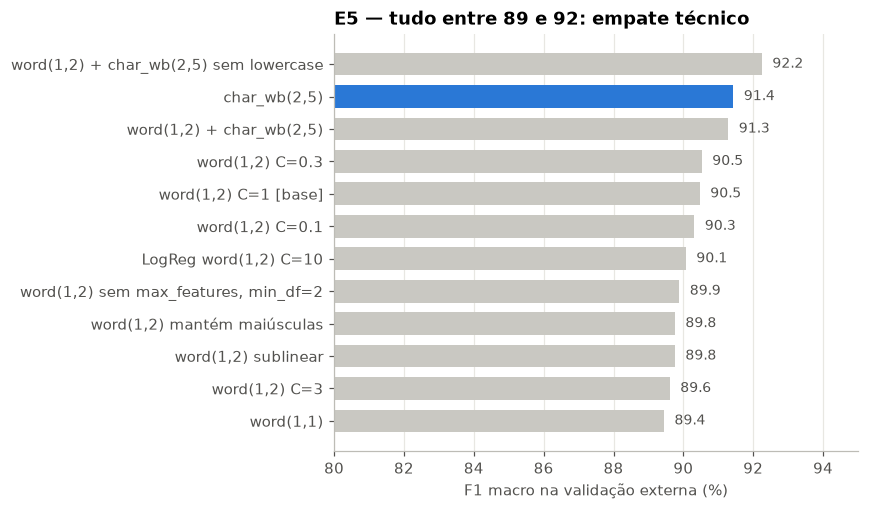

In [17]:
# O pipeline da variante char_wb(2,5), como criado em experimentos.fabricas_modelo().
print(experimentos.fabricas_modelo()["char_wb(2,5)"]())

e5 = tabela("E5 modelo")
barras(e5, "char_wb(2,5)", "E5 — tudo entre 89 e 92: empate técnico", xlim=(80, 95))

Todas as variações ficam entre 89,4 e 92,3. Os três modelos com caracteres estão no topo, mas dentro da faixa de
empate. **Para desempatar, a E6 mede robustez em fontes nunca vistas.**

### 5.7 E6 — O ganho é real ou é "assinatura de site"?

Treina **sem** uma fonte de cada classe (ex.: sem E-farsas e sem Agência Brasil) e valida só nelas.

In [18]:
e6 = res.loc[res["grupo"] == "E6 fontes", ["experimento", "f1_macro"]].copy()
e6[["modelo", "cenario"]] = e6["experimento"].str.split(" | ", regex=False, expand=True)
e6["cenario"] = e6["cenario"].str.replace(" no treino", "")
e6.pivot(index="modelo", columns="cenario", values="f1_macro").round(1)

cenario,sem Boatos.org/G1,sem E-farsas/Agência Brasil
modelo,,
fr2021,75.6,76.9
fr2021+ext,80.4,80.1
"fr2021+ext char_wb(2,5)",83.0,80.2
"fr2021+ext word(1,2) + char_wb(2,5) sem lowercase",81.8,76.6


**Leitura:**
- o corpus externo ajuda mesmo em fontes não vistas (+3 a +5 pontos): não é só assinatura de site;
- mas cai de ~90 para ~80 em fonte nova → **parte** do ganho é assinatura de site;
- `char_wb(2,5)` **nunca fica abaixo da base**; o 1º colocado da E5 (sem lowercase) perde 3,5 pontos em um dos
  cenários — as maiúsculas parecem ser estilo de cada site.

### 5.8 E7 — Embeddings pré-treinados

Vetores de frases de modelos multilíngues + regressão logística.

In [19]:
tabela("E7 embeddings")[["f1_macro", "recall_fake", "recall_true", "acerto_E-farsas"]]

,f1_macro,recall_fake,recall_true,acerto_E-farsas
experimento,,,,
emb multilingual-e5-small + LogReg C=0.3,89.3,89.5,90.8,61.8
emb multilingual-e5-small + LogReg C=1,89.7,86.6,93.1,61.8
emb multilingual-e5-small + LogReg C=3,90.5,85.9,94.5,61.8
emb multilingual-e5-small + LogReg C=10,91.8,87.0,95.7,61.8
emb paraphrase-multilingual-MiniLM-L12-v2 + LogReg C=0.3,83.8,76.2,90.7,41.2
emb paraphrase-multilingual-MiniLM-L12-v2 + LogReg C=1,85.8,75.8,93.8,44.1
emb paraphrase-multilingual-MiniLM-L12-v2 + LogReg C=3,86.1,76.5,93.8,44.1
emb paraphrase-multilingual-MiniLM-L12-v2 + LogReg C=10,87.0,76.9,94.8,41.2


O `multilingual-e5-small` empata com o `char_wb(2,5)` (91,8 × 91,4), mas exige PyTorch e um modelo de ~470 MB, não
usa o treino misto e não passou pela E6. **Não adotado.**

### 5.9 E8 — Hipótese do grupo: notícia verdadeira tem mais números?

A feature é a **proporção** de palavras que são número (ano, percentual, dinheiro, hora/data, outros dígitos,
número por extenso). Como 1 número em 8 palavras daria 12,5%, usamos uma versão "suavizada" que só confia no
percentual quando há palavras suficientes: `(n_numeros + m·p0) / (n_palavras + m)`.

In [20]:
# Contador de números (exp_numeros.py) aplicado a dois trechos.
true_ex = ("A projeção do mercado financeiro para a inflação oficial em 2026 subiu de 4,99% para 5,01%, "
           "segundo o Boletim Focus divulgado nesta segunda-feira (5) pelo Banco Central.")
fake_ex = ("Atenção, aposentado: se você não votar, seu benefício poderá ser cancelado. "
           "O voto agora serve como prova de vida.")
pd.DataFrame([exp_numeros.contar_numeros(true_ex), exp_numeros.contar_numeros(fake_ex)], index=["true", "fake"])

,ano,percentual,dinheiro,hora_data,outro_digito,extenso,n_palavras,n_numeros
true,1,2,0,0,1,0,27,4
fake,0,0,0,0,0,0,19,0


In [21]:
tabela("E8 números")[["f1_macro", "bal_acc", "recall_fake", "recall_true"]]

,f1_macro,bal_acc,recall_fake,recall_true
experimento,,,,
só tamanho (controle),49.7,54.7,9.4,100.0
só números: contagem,69.2,71.4,72.9,69.9
só números: pct,68.9,71.0,72.2,69.9
só números: pct_suave,68.9,71.0,72.2,69.9
só números: categorias,69.5,72.5,77.3,67.6
TF-IDF [base],90.5,89.7,83.8,95.7
TF-IDF + pct_suave (peso 1),90.5,89.7,83.8,95.7
TF-IDF + categorias (peso 0.3),90.5,89.8,84.1,95.5
TF-IDF + categorias (peso 1),90.5,89.8,84.1,95.5


**Conclusão da E8:** a hipótese é **verdadeira como observação** — nos três corpora as true têm mais números
(no externo, ~5% das palavras × ~2%; AUC 0,76). Sozinha, a feature chega a ~69 de F1. Mas **junto do TF-IDF ela não
acrescenta nada**: o SVM dá peso ~0 a ela, porque os próprios tokens ("2026", "14h30", "milhões") já estão no texto.
**Não entra no modelo.**

<a id="6"></a>
## 6. Escolha do modelo e pré-registro (antes de abrir o teste)

| Candidato | Val. externa (F1) | E6 sem E-farsas/AgB | E6 sem Boatos/G1 |
|---|---:|---:|---:|
| Candidato antigo (Fake.br + FR) | 82,9 | — | — |
| `fr2021 + ext`, palavras [base] | 90,5 | 80,1 | 80,4 |
| **`fr2021 + ext`, `char_wb(2,5)`** | **91,4** | **80,2** | **83,0** |
| `fr2021 + ext`, palavras + caracteres sem lowercase | 92,3 | 76,6 | 81,8 |
| `fr2021 + ext`, e5-small + LogReg | 91,8 | não medido | não medido |

**Escolhido: TF-IDF `char_wb(2,5)` (200k features, sublinear) + LinearSVC C=1 balanceado, treino misto 30/50/100,
dados `fr2021 + ext`.** Motivos:

1. está no grupo de topo da validação (empate técnico);
2. é o único do topo que **nunca perdeu para a base em fontes novas** (E6);
3. é o mais simples entre os empatados (sem PyTorch, leve, rápido);
4. n-gramas de caracteres fazem sentido para boatos (grafia, pontuação, erros).

> **O ganho real está nos dados, não no modelo:** ~83 (candidato) → ~90,5 (corpus externo) → ~91,4 (caracteres).

**Pré-registro (escrito antes de ler qualquer rótulo do teste):** 8 métodos avaliados de uma vez; métricas e
intervalos de confiança definidos antes; **o modelo escolhido não muda com o resultado do teste**. Os modelos foram
treinados e salvos ("congelados") em `modelos_finais/` **antes** de o teste ser lido.

In [22]:
# Avaliação final (avaliacao_final.py): congelar -> avaliar. O "avaliar" se recusa a rodar duas vezes.
import avaliacao_final
mostrar_codigo(avaliacao_final.congelar, avaliacao_final.metricas, avaliacao_final.avaliar)
print({nome: avaliacao_final.arquivo(nome) for nome in avaliacao_final.METODOS if avaliacao_final.METODOS[nome][0] != "historico"})

```python
def congelar():
    # Treina e salva cada método. Não lê nenhum teste.
    os.makedirs(PASTA_MODELOS, exist_ok=True)
    fontes, _, _ = fontes_de_treino()
    X, y = juntar(fontes, DADOS)
    for nome, (tipo, fab) in METODOS.items():
        if tipo == "historico":
            continue
        # Embeddings: treino em 50 palavras sem aumento misto (como na E7); demais: treino misto 30/50/100.
        modelo = fab().fit(X, y) if tipo == "emb" else treinar(X, y, fabrica=fab)
        joblib.dump(modelo, arquivo(nome))
        print("congelado:", nome, "->", arquivo(nome))
```

```python
def metricas(y, pred, fonte):
    acertos = int((y == pred).sum())
    lo, hi = wilson(acertos, len(y))
    f_lo, f_hi = ic_f1_bootstrap(y, pred)
    (tn_fake, fp_true), (fn_fake, tp_true) = confusion_matrix(y, pred, labels=["fake", "true"])
    linha = {"n": len(y), "accuracy": acertos / len(y) * 100, "acc_ic_baixo": lo, "acc_ic_alto": hi,
             "f1_macro": f1_score(y, pred, average="macro") * 100, "f1_ic_baixo": f_lo, "f1_ic_alto": f_hi,
             "bal_acc": balanced_accuracy_score(y, pred) * 100,
             "recall_fake": recall_score(y, pred, pos_label="fake") * 100,
             "recall_true": recall_score(y, pred, pos_label="true") * 100,
             "fake_como_fake": tn_fake, "fake_como_true": fp_true, "true_como_fake": fn_fake, "true_como_true": tp_true}
    for f, ok in pd.Series(y == pred).groupby(np.asarray(fonte)):
        linha[f"acerto_{f}"] = ok.mean() * 100
        linha[f"n_{f}"] = len(ok)
    return linha
```

```python
def avaliar():
    # Avaliação única. Recusa rodar de novo se já existir resultado (o teste só pode ser avaliado uma vez).
    if os.path.exists("resultados_teste_final.csv"):
        sys.exit("resultados_teste_final.csv já existe: a avaliação final já foi feita.")
    testes = {k: pd.read_csv(v) for k, v in TESTES.items()}
    testes["Testes 1 + 2"] = pd.concat(testes.values(), ignore_index=True)
    linhas, previsoes = [], []
    for nome, (tipo, fab) in METODOS.items():
        modelo = joblib.load(fab if tipo == "historico" else arquivo(nome))
        for teste, df in testes.items():
            X = truncar(df["texto"], N_PRODUTO)
            pred = np.asarray(modelo.predict(X))
            linhas.append({"metodo": nome, "teste": teste, **metricas(df["label"].values, pred, df["fonte"])})
            if teste != "Testes 1 + 2":
                previsoes.append(df.assign(teste=teste, metodo=nome, previsto=pred, texto_50=X))
        r = [l for l in linhas if l["metodo"] == nome]
        print(f"{nome}: " + " | ".join(f"{l['teste']}: F1 {l['f1_macro']:.1f} acc {l['accuracy']:.1f} "
                                        f"[{l['acc_ic_baixo']:.0f}-{l['acc_ic_alto']:.0f}]" for l in r))
    pd.DataFrame(linhas).to_csv("resultados_teste_final.csv", index=False, encoding="utf-8-sig")
    pd.concat(previsoes).to_csv("previsoes_teste_final.csv", index=False, encoding="utf-8-sig")
```

{'TF-IDF palavras [base]': 'modelos_finais\\02.joblib', 'TF-IDF caracteres [ESCOLHIDO]': 'modelos_finais\\03.joblib', 'TF-IDF palavras + caracteres (sem lowercase)': 'modelos_finais\\04.joblib', 'Embeddings e5-small + LogReg': 'modelos_finais\\05.joblib', 'Só números (E8)': 'modelos_finais\\06.joblib', 'TF-IDF palavras + números (E8)': 'modelos_finais\\07.joblib'}


<a id="7"></a>
## 7. Avaliação final única (05/10/2026)

- **Teste 1:** 39 notícias coletadas em 30/09/2026 (Agência Brasil, G1, Boatos.org, E-farsas).
- **Teste 2:** 77 notícias de 28/09 a 05/10/2026, coletadas depois do corpus (semana da eleição).
- Entrada cortada em 50 palavras. IC 95% do F1 por bootstrap (2.000 reamostragens).

Os resultados abaixo são **lidos** de `resultados_teste_final.csv` — a avaliação não é refeita.

In [23]:
final = pd.read_csv("resultados_teste_final.csv")
ESC = "TF-IDF caracteres [ESCOLHIDO]"

tab = final.pivot(index="metodo", columns="teste", values="f1_macro")
juntos = final[final["teste"] == "Testes 1 + 2"].set_index("metodo")
tab["IC 95% (1+2)"] = juntos.apply(lambda r: f"{r.f1_ic_baixo:.0f}–{r.f1_ic_alto:.0f}", axis=1)
tab["Recall fake (1+2)"] = juntos["recall_fake"]
tab["Recall true (1+2)"] = juntos["recall_true"]
tab = tab.loc[list(avaliacao_final.METODOS)]
tab

teste,Teste 1 (30/09),Teste 2 (02–05/10),Testes 1 + 2,IC 95% (1+2),Recall fake (1+2),Recall true (1+2)
metodo,,,,,,
Fake.br (modelo_final salvo),94.2,84.9,88.8,81–95,80.6,95.3
Fake.br + FakeRecogna (candidato salvo),88.5,87.6,88.2,80–94,74.2,97.6
TF-IDF palavras [base],88.0,93.9,91.7,85–97,77.4,100.0
TF-IDF caracteres [ESCOLHIDO],88.0,98.1,94.2,89–99,83.9,100.0
TF-IDF palavras + caracteres (sem lowercase),84.6,96.1,91.7,85–97,77.4,100.0
Embeddings e5-small + LogReg,88.0,94.2,91.9,85–97,80.6,98.8
Só números (E8),61.4,69.8,67.3,58–76,87.1,62.4
TF-IDF palavras + números (E8),88.0,93.9,91.7,85–97,77.4,100.0


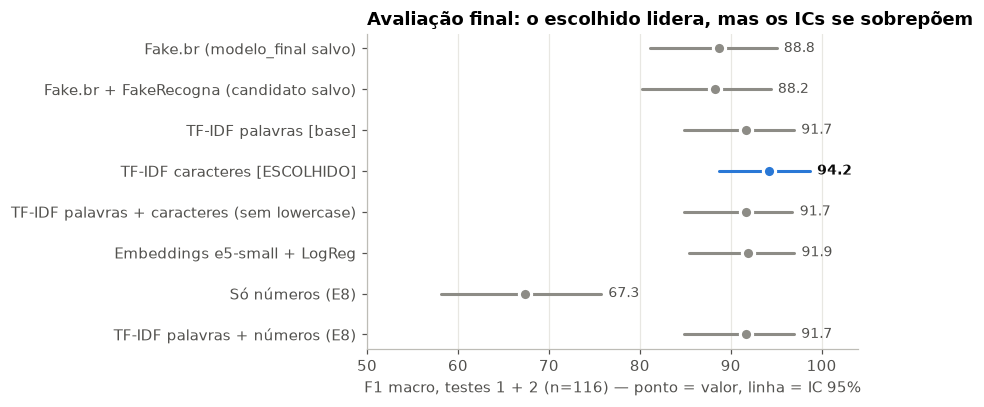

In [24]:
# F1 macro nos testes 1 + 2 com intervalo de confiança de 95%.
j = juntos.loc[list(avaliacao_final.METODOS)[::-1]]
fig, ax = plt.subplots(figsize=(8, 3.8))
for y, (nome, r) in enumerate(j.iterrows()):
    cor = COR["true"] if nome == ESC else "#8d8c86"
    ax.plot([r.f1_ic_baixo, r.f1_ic_alto], [y, y], color=cor, linewidth=2, solid_capstyle="round")
    ax.plot(r.f1_macro, y, "o", color=cor, markersize=8, markeredgecolor="white", markeredgewidth=2)
    ax.text(r.f1_ic_alto + 0.8, y, f"{r.f1_macro:.1f}", va="center", fontsize=9,
            color=TINTA if nome == ESC else TINTA2, fontweight="bold" if nome == ESC else "normal")
ax.set_yticks(range(len(j))); ax.set_yticklabels(j.index)
ax.set_xlim(50, 104); ax.set_xlabel("F1 macro, testes 1 + 2 (n=116) — ponto = valor, linha = IC 95%")
ax.grid(axis="y", visible=False)
ax.set_title("Avaliação final: o escolhido lidera, mas os ICs se sobrepõem")
plt.tight_layout(); plt.show()

**Leitura honesta:**
- o escolhido tem o maior F1 (94,2), mas os intervalos se sobrepõem com os outros modelos treinados com o corpus
  externo (~92) e até com os antigos (~88). **O teste confirma a direção da validação, mas não prova um vencedor**;
- com 14 fake no teste 1, cada previsão vale ~4 pontos de F1: as oscilações entre teste 1 e 2 são de amostra pequena.

### 7.1 Onde o modelo escolhido erra

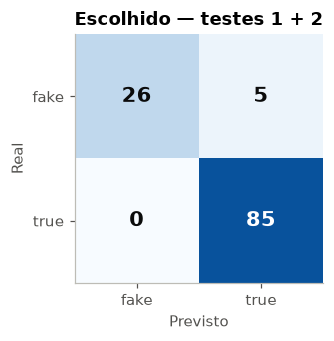

,teste,fonte,label,previsto,texto_50
0,Teste 1 (30/09),Boatos.org,fake,true,Bolsonaristas ateam fogo em imagem de Santa. Vídeo registra crime de intolerância religiosa no Pará. bolsonaristas t...
1,Teste 1 (30/09),Boatos.org,fake,true,"Caixão do cantor Rick pode pesar mais de 300 kg chama atenção E veja, o caixão milionário do cantor Rick pode pesar ..."
2,Teste 1 (30/09),Boatos.org,fake,true,"Ele comprou dois assentos no avião. Um pro lado dele. O outro continuava vazio, pra que a esposa que morreu pudesse ..."
3,Teste 1 (30/09),E-farsas,fake,true,"Um cientista brilhante preso entre linhas temporais. Um homem que surge em ruínas antigas, guerras futuras e eventos..."
4,Teste 2 (02–05/10),Boatos.org,fake,true,"ZANIN ASSUME O TSE ÀS VÉSPERAS DAS ELEIÇÕES DE 2026 O ministro Cristiano Zanin, que já atuou como advogado de Lula, ..."


In [25]:
# Matriz de confusão do escolhido nos testes 1 + 2.
r = juntos.loc[ESC]
m = np.array([[r.fake_como_fake, r.fake_como_true], [r.true_como_fake, r.true_como_true]], dtype=int)
fig, ax = plt.subplots(figsize=(3.8, 3.2))
ax.imshow(m, cmap="Blues", vmin=0, vmax=m.max() * 1.15)
for (i, k), v in np.ndenumerate(m):
    ax.text(k, i, v, ha="center", va="center", fontsize=14, fontweight="bold",
            color="white" if v > m.max() / 2 else TINTA)
ax.set_xticks([0, 1]); ax.set_xticklabels(["fake", "true"]); ax.set_yticks([0, 1]); ax.set_yticklabels(["fake", "true"])
ax.set_xlabel("Previsto"); ax.set_ylabel("Real"); ax.grid(False)
ax.set_title("Escolhido — testes 1 + 2")
plt.tight_layout(); plt.show()

# Os erros (todos são fake classificadas como true).
prev = pd.read_csv("previsoes_teste_final.csv")
erros = prev[(prev["metodo"] == ESC) & (prev["previsto"] != prev["label"])]
erros[["teste", "fonte", "label", "previsto", "texto_50"]].reset_index(drop=True)

- **Nenhuma notícia verdadeira foi marcada como fake** (85/85).
- Os 5 erros são **boatos escritos como notícia** ("Zanin assume o TSE… tomou posse") ou narrativas. É exatamente a
  limitação esperada: o modelo aprende **estilo de redação**, não verifica fatos.

**Estimativa final:** F1 ~94 [89–99] em notícias das mesmas fontes, na semana seguinte ao treino; **~80–83 esperado
em fontes que o modelo nunca viu** (E6).

<a id="8"></a>
## 8. O modelo escolhido por dentro

O arquivo `modelos_finais/03.joblib` é um `Pipeline` (TF-IDF → LinearSVC). Como o classificador é linear, dá para
ver quais n-gramas de caracteres mais empurram para cada classe (os espaços aparecem como `·`; o `char_wb` marca
início/fim de palavra com espaço).


modelos_finais/03.joblib: Pipeline
  tfidf: TfidfVectorizer {'max_features': 200000, 'ngram_range': (2, 5), 'min_df': 1, 'sublinear_tf': True, 'lowercase': True}
  svm: LinearSVC {'C': 1.0, 'class_weight': 'balanced', 'max_iter': 20000}
  vocabulário: 200000
  classes: ['fake', 'true']


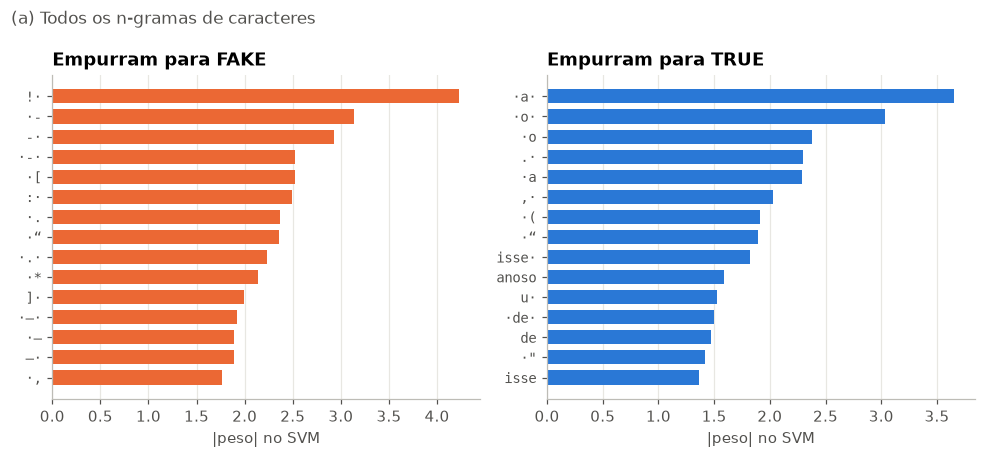

In [26]:
modelo = anls.inspecionar_modelo("modelos_finais/03.joblib")

nomes = modelo.named_steps["tfidf"].get_feature_names_out()
coef = modelo.named_steps["svm"].coef_.ravel()   # positivo -> true, negativo -> fake


def legivel(ng):
    # Espaço vira "·"; aspas do Windows (\x93/\x94) viram aspas curvas; outros caracteres invisíveis viram "?".
    ng = ng.replace(" ", "·").replace("\x93", "“").replace("\x94", "”")
    return "".join(ch if ch.isprintable() else "?" for ch in ng)


def grafico_ngramas(indices, titulo_geral, top=15):
    # Os `top` n-gramas de maior peso para cada lado, entre os índices permitidos.
    idx = np.asarray(indices)
    ordem = idx[np.argsort(coef[idx])]
    fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
    for ax, sel, lab, titulo in ((axes[0], ordem[:top][::-1], "fake", "Empurram para FAKE"),
                                 (axes[1], ordem[-top:], "true", "Empurram para TRUE")):
        ax.barh([legivel(nomes[i]) for i in sel], np.abs(coef[sel]), color=COR[lab], height=0.7)
        ax.set_title(titulo); ax.grid(axis="y", visible=False); ax.set_xlabel("|peso| no SVM")
        ax.tick_params(axis="y", labelsize=9)
        for t in ax.get_yticklabels():
            t.set_fontfamily("monospace")
    fig.suptitle(titulo_geral, x=0.01, ha="left", fontsize=11, color=TINTA2)
    plt.tight_layout(); plt.show()


# (a) Todos os n-gramas.
grafico_ngramas(np.arange(len(nomes)), "(a) Todos os n-gramas de caracteres")

**O que aparece no topo é pontuação e palavras gramaticais, não assunto:**
- para **fake**: `!`, travessões e hífens soltos, colchetes, aspas curvas, asteriscos — a "tipografia" de mensagem
  de WhatsApp e de texto copiado de redes sociais;
- para **true**: artigos e preposições (`a`, `o`, `de`) e o parêntese aberto — típico de frases longas e completas
  e do padrão "nesta segunda-feira **(5)**" da imprensa.

Para ver o vocabulário, o gráfico abaixo filtra só n-gramas que têm pelo menos 4 letras.

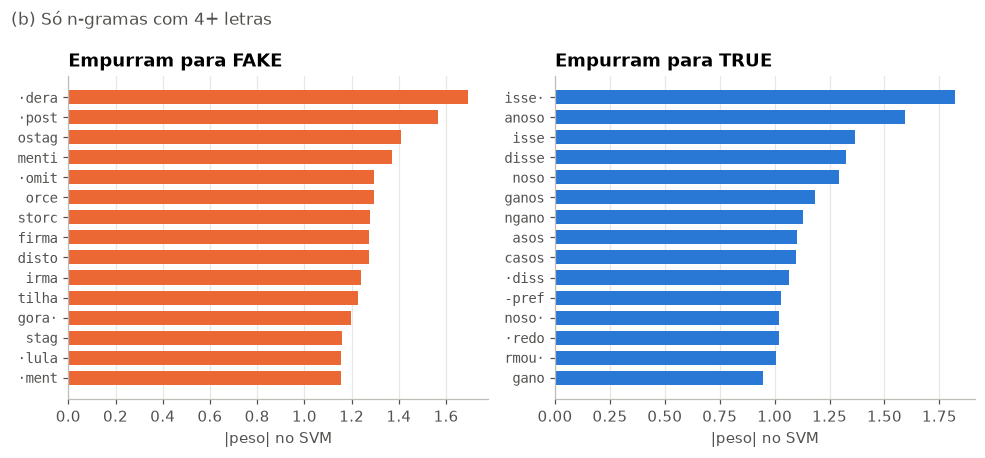

In [27]:
# (b) Só n-gramas com pelo menos 4 letras (mais fáceis de ler).
com_letras = [i for i, ng in enumerate(nomes) if sum(ch.isalpha() for ch in ng) >= 4]
grafico_ngramas(com_letras, "(b) Só n-gramas com 4+ letras")

Com letras, aparecem fragmentos como **"disse"**, "casos", "anos" e "-pref(eitura)" para *true* (atribuição de fala,
dados, órgãos públicos) e **"post(agem)"**, "menti(ra)", "omit(e)", "lula", "agora" para *fake* (apelo, política,
acusação). Juntos, os dois gráficos reforçam a leitura do mascaramento (seção 3): **o modelo é um detector de registro e de
estilo de redação** (pontuação, construção de frase, marcas do jornalismo profissional), e não um verificador de
fatos.

<a id="9"></a>
## 9. Demonstração

Exemplos reais dos testes (arquivo `modelo_para_compartilhar/exemplos.txt`). A entrada é cortada em 50 palavras e
a **confiança** é a distância até a fronteira de decisão do SVM (perto de 0 = dúvida; não é probabilidade).

> Demonstração não é medida de desempenho: exemplos escolhidos à mão não são amostra representativa.

In [28]:
# Lê os exemplos: a linha de comentário (#) antes de cada notícia é a descrição.
exemplos, desc = [], None
with open("modelo_para_compartilhar/exemplos.txt", encoding="utf-8") as f:
    for linha in f:
        linha = linha.strip()
        if linha.startswith("#"):
            desc = linha.lstrip("# ")
        elif linha:
            exemplos.append((desc, linha))


def analisar(texto, modelo=modelo):
    # Corta em 50 palavras, devolve a classe e a confiança (score do SVM).
    trecho = anls.truncar(pd.Series([" ".join(texto.split())]), 50).iloc[0]
    score = float(modelo.decision_function([trecho])[0])
    return ("TRUE" if score >= 0 else "FAKE"), round(abs(score), 2)


demo = pd.DataFrame([(d, t[:110] + "…", *analisar(t)) for d, t in exemplos],
                    columns=["caso", "trecho", "previsão", "confiança"])
demo["confiança"] = demo["confiança"].map("{:.2f}".format)
demo

,caso,trecho,previsão,confiança
0,Boato de WhatsApp sobre eleição (Boatos.org) - esperado FAKE,"Atenção, aposentado: se você não votar, seu benefício poderá ser cancelado. O voto agora serve como prova de v…",FAKE,1.85
1,Boato em CAIXA ALTA (Boatos.org) - esperado FAKE,URGENTE! PASSAPORTE DE FLÁVIO BOLSONARO É APREENDIDO! KÁSSIO NUNES RECUA! FLÁVIO BOLSONARO EM PÂNICO Descubra …,FAKE,2.20
2,Boato com Urgente!!! (Boatos.org) - esperado FAKE,Urgente!!! Polícia Militar de SP registra planos de ataque da facção do PCC em todo o Brasil. Os ataques seria…,FAKE,0.73
3,Boato escrito como notícia (Boatos.org) - o modelo ERRA e diz TRUE (limitação conhecida),"ZANIN ASSUME O TSE ÀS VÉSPERAS DAS ELEIÇÕES DE 2026 O ministro Cristiano Zanin, que já atuou como advogado de …",TRUE,0.61
4,Notícia do G1 - esperado TRUE,"Belém registrou 37 °C de temperatura máxima no sábado (3), a maior temperatura para o mês de outubro em 25 ano…",TRUE,2.20
5,Notícia da Agência Brasil - esperado TRUE,"A projeção do mercado financeiro para a inflação oficial em 2026 subiu de 4,99% para 5,01%, segundo o Boletim …",TRUE,1.75
6,"Notícia do G1 que fica perto da fronteira (acerta, mas com dúvida)","A Prefeitura de Sonora, a 360 quilômetros de Campo Grande, abriu inscrições para um processo seletivo simplifi…",TRUE,0.06


Teste com qualquer texto (edite a variável abaixo). Para a demonstração interativa completa, com vários modelos lado
a lado, use `testador_web.py` (navegador) ou `testar_noticia.py` (terminal).

In [29]:
minha_noticia = ("URGENTE!!! Compartilhem antes que apaguem: o governo vai confiscar a poupança de todos os "
                 "brasileiros na próxima semana. Meu primo que trabalha no banco confirmou!")
analisar(minha_noticia)

('FAKE', 1.95)

<a id="10"></a>
## 10. Limitações e conclusão

### Limitações
1. **O modelo aprende estilo, não fatos.** Um boato bem escrito, em padrão jornalístico, tende a passar como true
   (os 5 erros do teste final são desse tipo).
2. **Não distingue divulgar um boato de noticiar sua checagem** (texto de agência tende a sair como fake).
3. **Assinatura de site:** em fontes nunca vistas o desempenho esperado cai para ~80–83 (E6).
4. **Época:** fake do corpus externo até jul/2026 × true de ago–out/2026 — possível atalho de "assunto da época"
   que nem a validação nem o teste conseguem detectar.
5. **Amostras pequenas:** E-farsas tem 34 itens na validação e 1 no teste; os ICs do teste final são largos (89–99).
6. Foram testadas ~40 configurações na mesma validação: o número de topo da validação é otimista.
7. O corpus externo tem 42 especiais publicitários do G1 marcados como true (achado após o congelamento).

### Conclusão
- O ~97% histórico era, em grande parte, **o tamanho do texto**; truncar foi o passo que tornou a avaliação honesta.
- No Fake.br o limite era de **dados** (fake de um único site), não de modelo — grids e modelos mais complexos só
  empataram.
- O que mudou o patamar foi **coletar dados no formato do produto**: de ~83 para ~90 na validação externa.
- O modelo final é simples (TF-IDF de caracteres + SVM linear), rápido, interpretável e, no teste único, teve
  **F1 94,2 [89–99]** sem nenhuma notícia verdadeira marcada como falsa.

### Próximos passos
- **Teste 3** com notícias posteriores a 05/10, pré-registrado, avaliando só o modelo escolhido sem mudanças;
- remover os especiais publicitários do corpus externo e revalidar;
- split temporal para medir o atalho de época;
- calibrar o score em probabilidade para o produto.

---

### Apêndice — mapa dos arquivos

| Arquivo | Papel |
|---|---|
| `anls.py` | Carregamento/limpeza do Fake.br e FakeRecogna, funções do pipeline, números de controle |
| `coletar_teste_externo.py`, `conferir_teste_externo.py` | Coleta e conferência do teste 1 |
| `coletar_corpus_externo.py` | Coleta do corpus externo (treino/validação) |
| `experimentos.py` | Preparação do corpus e etapas E3–E7 |
| `exp_numeros.py` | Etapa E8 (feature de números) |
| `coletar_teste2.py`, `conferir_teste2.py` | Coleta e conferência do teste 2 |
| `avaliacao_final.py` | Congelamento dos modelos e avaliação única |
| `modelos_finais/03.joblib` | **Modelo escolhido** |
| `resultados_experimentos.csv`, `resultados_teste_final.csv` | Todos os números desta apresentação |
| `testador_web.py`, `testar_noticia.py` | Demonstração interativa |
| `README.md`, `EXPERIMENTOS.md` | Contexto, decisões e log completo |